# CITS quickstart

This notebook runs CITS (Causal Inference in Time Series) on small simulated datasets with known ground truth. It needs no GPU and runs in a few minutes.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abbasilab/cits/blob/main/examples/quickstart.ipynb)

Paper: [arXiv:2508.01920](https://arxiv.org/abs/2508.01920). Code: [github.com/abbasilab/cits](https://github.com/abbasilab/cits).

## Install

The `rcit` extra adds PyTorch for the nonlinear test, and `viz` adds the plotting helpers. On Colab PyTorch is already installed, so this takes well under a minute.

In [1]:
%pip install -q --disable-pip-version-check "cits[rcit,viz]"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cits
from cits import methods, simulate_timeseries
print("cits", cits.__version__)

cits 1.9.1


## 1. Linear Gaussian data

`simulate_timeseries.simulate` returns the time series `X` with shape `(p, T)`, the ground-truth adjacency, and the true edge weights. In `lingauss1`, variables 0 and 1 drive variable 2, and variable 2 drives variable 3.

In [3]:
X, gt_adj, gt_weights = simulate_timeseries.simulate('lingauss1', noise=1.0, T=2000)
print("X shape:", X.shape)
print("ground truth (entry [i, j] = 1 means i -> j):")
print(gt_adj)

X shape: (4, 2000)
ground truth (entry [i, j] = 1 means i -> j):
[[0 0 1 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]


`methods.cits_full` is the reference algorithm. It searches all conditioning sets and uses the partial-correlation test, which suits linear Gaussian data. It takes about half a minute here.

In [4]:
adj = methods.cits_full(X, tau=1, alpha=0.05)
print("inferred:")
print(adj)
print("matches ground truth:", np.array_equal(adj, gt_adj))

inferred:
[[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]
matches ground truth: True


## 2. Signed edge weights

`methods.cits_full_weighted` also returns a signed weight for each inferred edge. It comes from a linear regression of each variable on its inferred parents. Here the true weights are 2, −1 and 2.

In [5]:
adj, weights = methods.cits_full_weighted(X, tau=1, alpha=0.05)
np.set_printoptions(precision=2, suppress=True)
print("inferred signed weights (0 = no edge):")
print(np.asarray(weights))
print("true weights:")
print(gt_weights)

inferred signed weights (0 = no edge):
[[ 0.    0.    2.04  0.  ]
 [ 0.    0.   -0.97  0.  ]
 [ 0.    0.    0.    1.98]
 [ 0.    0.    0.    0.  ]]
true weights:
[[ 0.  0.  2.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0.  2.]
 [ 0.  0.  0.  0.]]


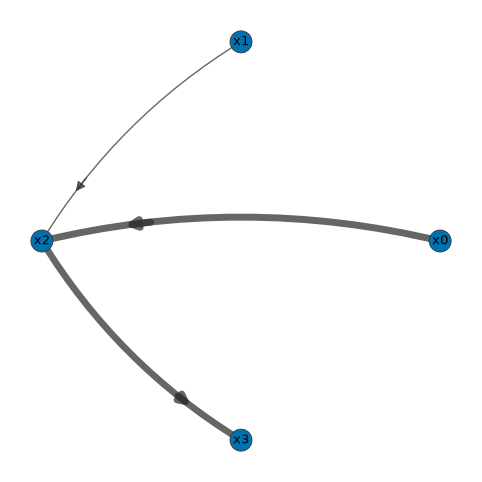

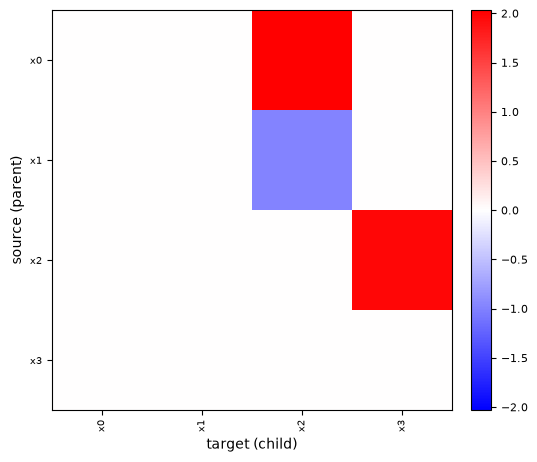

In [6]:
labels = ['x0', 'x1', 'x2', 'x3']
W = np.asarray(weights)
cits.plot_graph(W, labels=labels)
plt.show()
cits.plot_matrix(W, labels=labels)
plt.show()

## 3. Nonlinear, non-Gaussian data

In `nonlinnongauss1` the couplings are sinusoidal and the noise is uniform. `cits.cits_rcit` uses the RCIT kernel test, which detects nonlinear dependence. It runs on a GPU when one is available and on the CPU otherwise, and takes a few seconds here.

In [7]:
Xn, gt_n, _ = simulate_timeseries.simulate('nonlinnongauss1', noise=1.0, T=2000)
Bn = cits.cits_rcit(Xn, alpha=0.05, tau=1)
print("inferred:")
print(Bn)
print("matches ground truth:", np.array_equal(Bn, gt_n))

inferred:
[[0 0 1 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]
matches ground truth: True


## 4. Your own data

Arrange the recording as a NumPy array of shape `(p, T)`, with one row per variable (for example a neuron) and one column per time bin. Then pick the function by your data and graph size.

| Function | Use it for |
|---|---|
| `cits.methods.cits_full` | small graphs with linear or approximately Gaussian data |
| `cits.cits_rcit` | nonlinear or non-Gaussian data, such as spike counts |
| `cits.cits_gpu` | large graphs, up to thousands of variables, on a GPU (needs cuPC) |
| `cits.cits_contemporaneous` | slow sampling, where same-time edges matter |

On Colab, choose Runtime, then Change runtime type, then a GPU, to speed up `cits_rcit`. See the [README](https://github.com/abbasilab/cits#readme) for parameters and GPU setup.

In [8]:
# X = np.load('my_recording.npy')          # shape (p, T)
# B = cits.cits_rcit(X, alpha=0.05, tau=1)